# Итоговый анализ NL2SQL

Ноутбук содержит итоговый анализ экспериментальных результатов в задаче `NL2SQL`. Его цель — проверить гипотезу о том, что специализированная компактная модель может обеспечивать качество генерации SQL, сопоставимое с качеством универсальной большой языковой модели, при другом вычислительном профиле.

Основная часть анализа опирается на сопоставимые результаты в режиме `EA`. Основной метрикой качества выступает `Execution Accuracy (EA)`. Дополнительные метрики — интегральная метрика вычислительной эффективности `Eff` и `Pass@K`. Метрика `Eff` нужна для оценки вычислительного профиля моделей, а `Pass@K` — для анализа поведения моделей в режиме многократной генерации.

## Содержание

1. Данные и воспроизводимость
2. Исследовательская постановка
3. Состав сравниваемых моделей
4. Распределение EA на уровне агрегированных результатов
5. Проверка гипотезы и оценка достижимого уровня качества
6. Парные сравнения на общем наборе задач
7. Структурные различия между Spider и BIRD
8. Интегральная метрика вычислительной эффективности и ее компоненты
9. Ограничения исследования
10. Приложение A: Дополнительные результаты EA
11. Приложение B: Pass@K
12. Приложение C: Результаты локального синтетического бенчмарка
13. Итоговые выводы


## 1. Данные и воспроизводимость

В этом разделе загружаются итоговые артефакты экспериментов и фиксируется источник данных, на котором основан анализ. Ноутбук работает поверх уже рассчитанных результатов из `results/nl2sql` и воспроизводит итоговые таблицы и графики без повторного запуска инференса.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

from pathlib import Path
from typing import Any, cast

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

from nl2sql.notebooks.analysis_utils import (
    RESULTS_DIR,
    build_completeness_audit,
    compute_pairwise_ea_deltas,
    compute_sample_outcomes,
    filter_appendix_rows,
    filter_main_report_rows,
    get_expected_sample_counts,
    get_figures_dir,
    load_records,
    load_summary_metrics,
    reset_analysis_caches,
)

sns.set_theme(style='whitegrid', context='talk')
pd.options.display.float_format = '{:.4f}'.format

RUN_LABEL = 'ea'
PASS_K_LABEL = 'pass_k'
EXPECTED_COUNTS = get_expected_sample_counts(RUN_LABEL)
FIGURES_DIR = get_figures_dir('final')
palette = {'m1': '#1b9e77', 'm2': '#d95f02'}


## 2. Исследовательская постановка

В работе проверяется следующая гипотеза:

> специализированная компактная модель способна обеспечивать качество генерации SQL, сопоставимое с качеством большой универсальной модели, при ином профиле вычислительных затрат.

Основной метрикой качества в этом сравнении является `EA`, поскольку она показывает долю задач, в которых модель с первой попытки строит SQL-запрос, эквивалентный эталону по результату исполнения. Вычислительная эффективность рассматривается отдельно через интегральную метрику `Eff`, а `Pass@K` используется как вспомогательная характеристика режима многократной генерации. Эти метрики решают разные задачи и не подменяют друг друга.

## 3. Состав сравниваемых моделей

Перед сравнительным анализом фиксируется состав сопоставимого корпуса результатов. В основную часть исследования включаются только модели, для которых доступны сопоставимые значения `EA` на бенчмарках `Spider` и `BIRD`. Это делает межмодельное сравнение корректным.

Итоговый вывод строится по единому набору задач, на котором все сравниваемые модели наблюдаются в одинаковых условиях.

In [2]:
reset_analysis_caches()
ea_samples_df, ea_generations_df = load_records(RUN_LABEL)
ea_summary_df = cast(Any, load_summary_metrics(RUN_LABEL).copy())
ea_outcomes_df = cast(Any, compute_sample_outcomes(RUN_LABEL).copy())
ea_audit_df = cast(Any, build_completeness_audit(RUN_LABEL, summary_df=ea_summary_df, expected_counts=EXPECTED_COUNTS))
main_ea_df = cast(Any, filter_main_report_rows(ea_summary_df, run_label=RUN_LABEL, audit_df=ea_audit_df))
appendix_ea_df = cast(Any, filter_appendix_rows(ea_summary_df, run_label=RUN_LABEL, audit_df=ea_audit_df))
main_model_names = sorted(main_ea_df['model_name'].unique().tolist())
appendix_model_names = sorted(appendix_ea_df['model_name'].unique().tolist())

display(Markdown(f'**Источник данных и артефактов:** `{RESULTS_DIR}`'))

comparison_view = ea_audit_df[[
    'model_display_name',
    'model_family',
    'spider_n_samples',
    'bird_n_samples',
    'is_complete',
]].copy()
comparison_view = comparison_view[comparison_view['model_display_name'].isin(set(main_ea_df['model_display_name']))].rename(columns={
    'model_display_name': 'Модель',
    'model_family': 'Класс модели',
    'spider_n_samples': 'Число задач Spider',
    'bird_n_samples': 'Число задач BIRD',
    'is_complete': 'Включена в сравнение',
})
display(Markdown('**Таблица 1. Состав моделей, включенных в основное сравнение**'))
display(comparison_view.sort_values(['Класс модели', 'Модель']).reset_index(drop=True))
display(Markdown(f'**Модели, включенные в основное сравнение:** {sorted(main_ea_df["model_display_name"].unique().tolist())}'))
if appendix_model_names:
    display(Markdown('Дополнительные результаты приведены в приложении A.'))

**Источник данных и артефактов:** `/home/count/code/vkr/results/nl2sql`

**Таблица 1. Состав моделей, включенных в основное сравнение**

,Модель,Класс модели,Число задач Spider,Число задач BIRD,Включена в сравнение
0,ChatGPT 5.2,m1,1034,1534,True
1,DeepSeek V3.2,m1,1034,1534,True
2,Arctic-Text2SQL-R1-7B,m2,1034,1534,True
3,Defog-Llama3-SQLCoder-8B q4_0,m2,1034,1534,True
4,Hrida-T2SQL q8_0,m2,1034,1534,True


**Модели, включенные в основное сравнение:** ['Arctic-Text2SQL-R1-7B', 'ChatGPT 5.2', 'DeepSeek V3.2', 'Defog-Llama3-SQLCoder-8B q4_0', 'Hrida-T2SQL q8_0']

Дополнительные результаты приведены в приложении A.

## 4. Распределение `EA` на уровне агрегированных результатов

Для каждой модели рассматривается не только среднее значение `EA`, но и bootstrap-оценка распределения агрегированной метрики через квантили `q05`, `q50` и `q95`. Такой способ представления дает не одну точку, а интервал значений и делает последующий сравнительный вывод более надежным.

In [3]:
ea_view_cols = [
    'model_display_name', 'model_family', 'benchmark', 'n_samples',
    'execution_accuracy', 'execution_accuracy_q05', 'execution_accuracy_q50', 'execution_accuracy_q95',
]
ea_view_df = main_ea_df[ea_view_cols].sort_values(['benchmark', 'model_family', 'execution_accuracy'], ascending=[True, True, False])
ea_view_display = ea_view_df.rename(columns={
    'model_display_name': 'Модель',
    'model_family': 'Класс модели',
    'benchmark': 'Бенчмарк',
    'n_samples': 'Число задач',
    'execution_accuracy': 'EA',
    'execution_accuracy_q05': 'EA q05',
    'execution_accuracy_q50': 'EA q50',
    'execution_accuracy_q95': 'EA q95',
})
display(Markdown('**Таблица 2. Основные значения `EA` и bootstrap-квантили для сопоставимого набора моделей**'))
display(ea_view_display.round(4))

**Таблица 2. Основные значения `EA` и bootstrap-квантили для сопоставимого набора моделей**

,Модель,Класс модели,Бенчмарк,Число задач,EA,EA q05,EA q50,EA q95
0,ChatGPT 5.2,m1,bird,1534,0.3657,0.3468,0.3657,0.3853
1,DeepSeek V3.2,m1,bird,1534,0.3227,0.3031,0.3227,0.3422
2,Arctic-Text2SQL-R1-7B,m2,bird,1534,0.5385,0.5150,0.5388,0.5593
3,Defog-Llama3-SQLCoder-8B q4_0,m2,bird,1534,0.2634,0.2458,0.2634,0.2823
4,Hrida-T2SQL q8_0,m2,bird,1534,0.1551,0.1402,0.1551,0.1701
5,ChatGPT 5.2,m1,spider,1034,0.7427,0.7195,0.7427,0.7650
6,DeepSeek V3.2,m1,spider,1034,0.7369,0.7147,0.7369,0.7592
7,Arctic-Text2SQL-R1-7B,m2,spider,1034,0.7718,0.7495,0.7718,0.7921
8,Defog-Llama3-SQLCoder-8B q4_0,m2,spider,1034,0.5629,0.5387,0.5629,0.5880
9,Hrida-T2SQL q8_0,m2,spider,1034,0.4913,0.4652,0.4913,0.5155


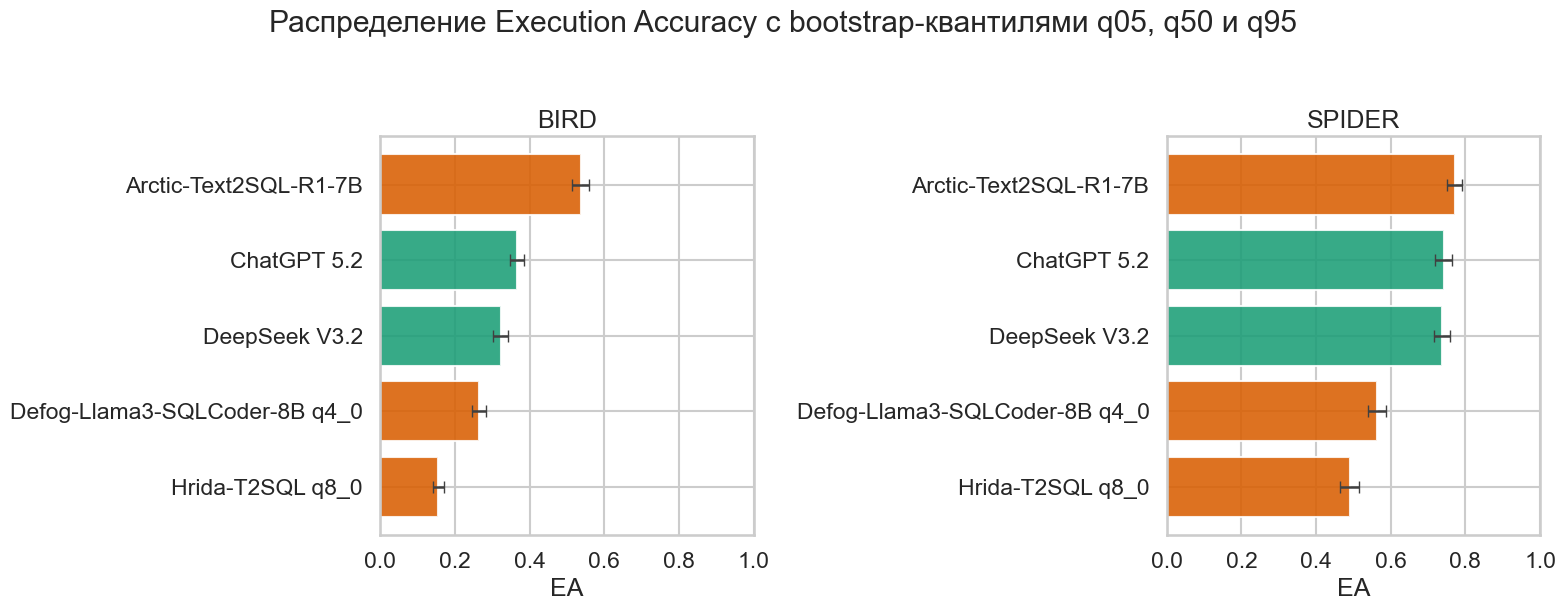

In [4]:
benchmarks = list(ea_view_df['benchmark'].dropna().unique())
fig, axes = plt.subplots(1, len(benchmarks), figsize=(8 * max(len(benchmarks), 1), 6), sharex=False)
if len(benchmarks) == 1:
    axes = [axes]
for ax, benchmark in zip(axes, benchmarks):
    subset = ea_view_df[ea_view_df['benchmark'] == benchmark].sort_values('execution_accuracy')
    y = np.arange(len(subset))
    x = subset['execution_accuracy'].to_numpy()
    lower = x - subset['execution_accuracy_q05'].to_numpy()
    upper = subset['execution_accuracy_q95'].to_numpy() - x
    colors = subset['model_family'].map(palette).tolist()
    ax.barh(y, x, color=colors, alpha=0.88)
    ax.errorbar(x, y, xerr=np.vstack([lower, upper]), fmt='none', ecolor='0.25', capsize=4, linewidth=1.8)
    ax.set_yticks(y)
    ax.set_yticklabels(subset['model_display_name'])
    ax.set_xlim(0, 1)
    ax.set_title(benchmark.upper())
    ax.set_xlabel('EA')
fig.suptitle('Распределение Execution Accuracy с bootstrap-квантилями q05, q50 и q95', y=1.03)
fig.tight_layout()
plt.show()


Визуализация показывает, что различия между моделями устойчиво воспроизводятся на обоих бенчмарках, но их масштаб заметно зависит от сложности набора. Уже здесь видно, что `Spider` и `BIRD` дают разную картину сравнения: на `Spider` значения `EA` в целом выше, а на `BIRD` интервалы смещены вниз для всех моделей.

## 5. Проверка гипотезы и оценка достижимого уровня качества

В этом разделе результаты `EA` интерпретируются в логике проверяемой гипотезы: оценивается, можно ли считать качество специализированных компактных моделей сопоставимым с качеством больших универсальных моделей на `Spider` и `BIRD`, и при каких условиях это утверждение сохраняется.

Сначала рассматриваются лучшие представители классов `M1` и `M2`, после чего отдельно оценивается, достигают ли они уровня качества, близкого к диапазону `EA = 0.8-0.9`.

In [5]:
best_by_family_df = cast(Any, (
    main_ea_df.sort_values(['benchmark', 'model_family', 'execution_accuracy'], ascending=[True, True, False])
    .groupby(['benchmark', 'model_family'], as_index=False)
    .first()
))
best_by_family_df['delta_to_other_family'] = np.nan
for benchmark in sorted(best_by_family_df['benchmark'].unique()):
    subset = best_by_family_df[best_by_family_df['benchmark'] == benchmark].set_index('model_family')
    if {'m1', 'm2'}.issubset(subset.index):
        best_by_family_df.loc[(best_by_family_df['benchmark'] == benchmark) & (best_by_family_df['model_family'] == 'm2'), 'delta_to_other_family'] = subset.loc['m2', 'execution_accuracy'] - subset.loc['m1', 'execution_accuracy']
        best_by_family_df.loc[(best_by_family_df['benchmark'] == benchmark) & (best_by_family_df['model_family'] == 'm1'), 'delta_to_other_family'] = subset.loc['m1', 'execution_accuracy'] - subset.loc['m2', 'execution_accuracy']

best_by_family_view = best_by_family_df[['benchmark', 'model_family', 'model_display_name', 'execution_accuracy', 'execution_accuracy_q05', 'execution_accuracy_q95', 'delta_to_other_family']].copy()
best_by_family_view = best_by_family_view.rename(columns={
    'benchmark': 'Бенчмарк',
    'model_family': 'Класс модели',
    'model_display_name': 'Лучшая модель в классе',
    'execution_accuracy': 'EA',
    'execution_accuracy_q05': 'EA q05',
    'execution_accuracy_q95': 'EA q95',
    'delta_to_other_family': 'Разность EA с другим классом',
})
display(Markdown('**Таблица 3. Лучшие представители классов `M1` и `M2` по метрике `EA`**'))
display(best_by_family_view.round(4))

**Таблица 3. Лучшие представители классов `M1` и `M2` по метрике `EA`**

,Бенчмарк,Класс модели,Лучшая модель в классе,EA,EA q05,EA q95,Разность EA с другим классом
0,bird,m1,ChatGPT 5.2,0.3657,0.3468,0.3853,-0.1728
1,bird,m2,Arctic-Text2SQL-R1-7B,0.5385,0.5150,0.5593,0.1728
2,spider,m1,ChatGPT 5.2,0.7427,0.7195,0.7650,-0.0290
3,spider,m2,Arctic-Text2SQL-R1-7B,0.7718,0.7495,0.7921,0.0290


In [6]:
target_rows = []
for benchmark, subset in best_by_family_df.groupby('benchmark'):
    for family in ['m1', 'm2']:
        row = subset[subset['model_family'] == family].iloc[0]
        target_rows.append({
            'Бенчмарк': benchmark,
            'Класс модели': family,
            'Лучшая модель': row['model_display_name'],
            'EA': row['execution_accuracy'],
            'Попадание в диапазон 0.8-0.9': bool(0.8 <= row['execution_accuracy'] <= 0.9),
        })
target_df = pd.DataFrame(target_rows)
display(Markdown('**Таблица 4. Проверка достижения диапазона `EA = 0.8-0.9`**'))
display(target_df)

**Таблица 4. Проверка достижения диапазона `EA = 0.8-0.9`**

,Бенчмарк,Класс модели,Лучшая модель,EA,Попадание в диапазон 0.8-0.9
0,bird,m1,ChatGPT 5.2,0.3657,False
1,bird,m2,Arctic-Text2SQL-R1-7B,0.5385,False
2,spider,m1,ChatGPT 5.2,0.7427,False
3,spider,m2,Arctic-Text2SQL-R1-7B,0.7718,False


Сопоставление лучших представителей классов `M1` и `M2` показывает, что вопрос о сопоставимости качества нельзя решать без учета конкретного бенчмарка. На `Spider` различие между сильнейшими представителями классов невелико, тогда как на `BIRD` преимущество специализированной модели выражено заметно сильнее. Одновременно проверка диапазона `EA = 0.8-0.9` показывает, что ни один из рассматриваемых кандидатов не достигает этого уровня на полном наборе задач.

## 6. Парные сравнения на общем наборе задач

Чтобы не ограничиваться сравнением агрегированных средних, далее рассчитывается `ΔEA` на одних и тех же задачах для каждой пары моделей. Такой анализ позволяет оценить не только величину различия, но и его устойчивость на общем наборе наблюдений.

In [7]:
pairwise_df = cast(Any, compute_pairwise_ea_deltas(RUN_LABEL, outcomes_df=ea_outcomes_df, allowed_models=main_model_names))
pairwise_view = pairwise_df[['benchmark', 'comparison', 'matched_samples', 'left_ea', 'right_ea', 'delta_ea', 'delta_ea_q05', 'delta_ea_q50', 'delta_ea_q95']].copy()
pairwise_view = pairwise_view.rename(columns={
    'benchmark': 'Бенчмарк',
    'comparison': 'Сравнение моделей',
    'matched_samples': 'Число общих задач',
    'left_ea': 'EA модели A',
    'right_ea': 'EA модели B',
    'delta_ea': 'ΔEA',
    'delta_ea_q05': 'ΔEA q05',
    'delta_ea_q50': 'ΔEA q50',
    'delta_ea_q95': 'ΔEA q95',
})
display(Markdown('**Таблица 5. Парные различия `EA` на общем наборе задач**'))
display(pairwise_view.round(4))

**Таблица 5. Парные различия `EA` на общем наборе задач**

,Бенчмарк,Сравнение моделей,Число общих задач,EA модели A,EA модели B,ΔEA,ΔEA q05,ΔEA q50,ΔEA q95
0,bird,Arctic-Text2SQL-R1-7B vs Hrida-T2SQL q8_0,1534,0.5385,0.1551,0.3833,0.3618,0.3827,0.4042
1,bird,Arctic-Text2SQL-R1-7B vs Defog-Llama3-SQLCoder...,1534,0.5385,0.2634,0.2751,0.2516,0.2751,0.2979
2,bird,Arctic-Text2SQL-R1-7B vs DeepSeek V3.2,1534,0.5385,0.3227,0.2158,0.1930,0.2145,0.2373
3,bird,ChatGPT 5.2 vs Hrida-T2SQL q8_0,1534,0.3657,0.1551,0.2106,0.1890,0.2112,0.2353
4,bird,Arctic-Text2SQL-R1-7B vs ChatGPT 5.2,1534,0.5385,0.3657,0.1728,0.1493,0.1721,0.1956
5,bird,DeepSeek V3.2 vs Hrida-T2SQL q8_0,1534,0.3227,0.1551,0.1675,0.1454,0.1682,0.1910
6,bird,Defog-Llama3-SQLCoder-8B q4_0 vs Hrida-T2SQL q8_0,1534,0.2634,0.1551,0.1082,0.0893,0.1082,0.1271
7,bird,ChatGPT 5.2 vs Defog-Llama3-SQLCoder-8B q4_0,1534,0.3657,0.2634,0.1023,0.0808,0.1030,0.1258
8,bird,DeepSeek V3.2 vs Defog-Llama3-SQLCoder-8B q4_0,1534,0.3227,0.2634,0.0593,0.0384,0.0593,0.0854
9,bird,ChatGPT 5.2 vs DeepSeek V3.2,1534,0.3657,0.3227,0.0430,0.0274,0.0430,0.0600


Парные сравнения уточняют вывод по средним значениям: различия между моделями возникают не из-за нескольких отдельных выбросов, а сохраняются на общем наборе задач. Это особенно важно для `BIRD`, где преимущество сильнейшей специализированной модели относительно лучших `M1` выглядит устойчивым, а не случайным.

## 7. Структурные различия между Spider и BIRD

Оценивать сопоставимость качества только по `Spider` недостаточно. `Spider` и `BIRD` различаются не только формально, но и содержательно: на более реалистичном и сложном бенчмарке поведение моделей меняется, и именно это задает границы применимости итогового вывода.

In [8]:
BENCHMARK_LABELS = {
    'bird': 'BIRD',
    'spider': 'Spider',
    'synthetic_ecommerce': 'SEB',
}
DIFFICULTY_LABELS = {
    'easy': 'простые',
    'medium': 'средние',
    'hard': 'сложные',
    'simple': 'простые',
    'moderate': 'средние',
    'challenging': 'сложные',
}
OUTCOME_LABELS = {
    'correct': 'корректный результат',
    'execution_error': 'ошибка выполнения',
    'empty_sql': 'пустой SQL',
    'result_mismatch': 'некорректный результат',
    'wrong_result': 'некорректный результат',
}

main_outcomes_df = cast(Any, ea_outcomes_df[ea_outcomes_df['model_name'].isin(main_model_names)].copy())
main_outcomes_df['benchmark_ru'] = main_outcomes_df['benchmark'].map(BENCHMARK_LABELS).fillna(main_outcomes_df['benchmark'])
main_outcomes_df['difficulty_ru'] = main_outcomes_df['difficulty'].map(DIFFICULTY_LABELS).fillna(main_outcomes_df['difficulty'])

def categorize_error(row: pd.Series) -> str:
    if bool(row['first_hit']):
        return 'correct'
    if bool(row.get('empty_sql', False)):
        return 'empty_sql'
    if not bool(row.get('first_pred_success', False)):
        return 'execution_error'
    return 'wrong_result'

main_outcomes_df['error_type'] = main_outcomes_df.apply(categorize_error, axis=1)
main_outcomes_df['outcome_ru'] = main_outcomes_df['error_type'].map(OUTCOME_LABELS).fillna(main_outcomes_df['error_type'])

difficulty_df = (
    main_outcomes_df.dropna(subset=['difficulty_ru'])
    .groupby(['benchmark', 'benchmark_ru', 'difficulty_ru'], as_index=False)['first_hit']
    .mean()
    .rename(columns={'first_hit': 'ea'})
)
main_outcomes_df['question_len_bucket'] = pd.qcut(main_outcomes_df['question_len'], q=4, duplicates='drop')
question_len_df = (
    main_outcomes_df.groupby(['benchmark', 'benchmark_ru', 'question_len_bucket'], as_index=False, observed=False)['first_hit']
    .mean()
    .rename(columns={'first_hit': 'ea'})
)
question_len_df['question_len_bucket_ru'] = question_len_df['question_len_bucket'].astype(str)
error_mix_df = (
    main_outcomes_df.groupby(['benchmark', 'benchmark_ru', 'error_type', 'outcome_ru']).size().rename('count').reset_index()
)
error_mix_df['share'] = error_mix_df['count'] / error_mix_df.groupby('benchmark')['count'].transform('sum')

difficulty_view = difficulty_df.rename(columns={
    'benchmark_ru': 'Набор данных',
    'difficulty_ru': 'Уровень сложности',
    'ea': 'EA',
})[['Набор данных', 'Уровень сложности', 'EA']]
question_len_view = question_len_df.rename(columns={
    'benchmark_ru': 'Набор данных',
    'question_len_bucket_ru': 'Интервал длины вопроса',
    'ea': 'EA',
})[['Набор данных', 'Интервал длины вопроса', 'EA']]
error_mix_view = error_mix_df[['benchmark_ru', 'outcome_ru', 'share']].rename(columns={
    'benchmark_ru': 'Набор данных',
    'outcome_ru': 'Тип исхода',
    'share': 'Доля',
})

display(Markdown('**Таблица 6. `EA` по уровням сложности**'))
display(difficulty_view.round(4))
display(Markdown('**Таблица 7. `EA` по интервалам длины вопроса**'))
display(question_len_view.round(4))
display(Markdown('**Таблица 8. Структура исходов выполнения**'))
display(error_mix_view.round(4))


**Таблица 6. `EA` по уровням сложности**

,Набор данных,Уровень сложности,EA
0,BIRD,простые,0.4004
1,BIRD,сложные,0.2028
2,BIRD,средние,0.2263


**Таблица 7. `EA` по интервалам длины вопроса**

,Набор данных,Интервал длины вопроса,EA
0,BIRD,"(17.999, 56.0]",0.4800
1,BIRD,"(56.0, 72.0]",0.3485
2,BIRD,"(72.0, 92.0]",0.3010
3,BIRD,"(92.0, 286.0]",0.2420
4,Spider,"(17.999, 56.0]",0.7587
5,Spider,"(56.0, 72.0]",0.6878
6,Spider,"(72.0, 92.0]",0.5831
7,Spider,"(92.0, 286.0]",0.5007


**Таблица 8. Структура исходов выполнения**

,Набор данных,Тип исхода,Доля
0,BIRD,корректный результат,0.3291
1,BIRD,ошибка выполнения,0.1806
2,BIRD,некорректный результат,0.4904
3,Spider,корректный результат,0.6611
4,Spider,ошибка выполнения,0.0603
5,Spider,некорректный результат,0.2785


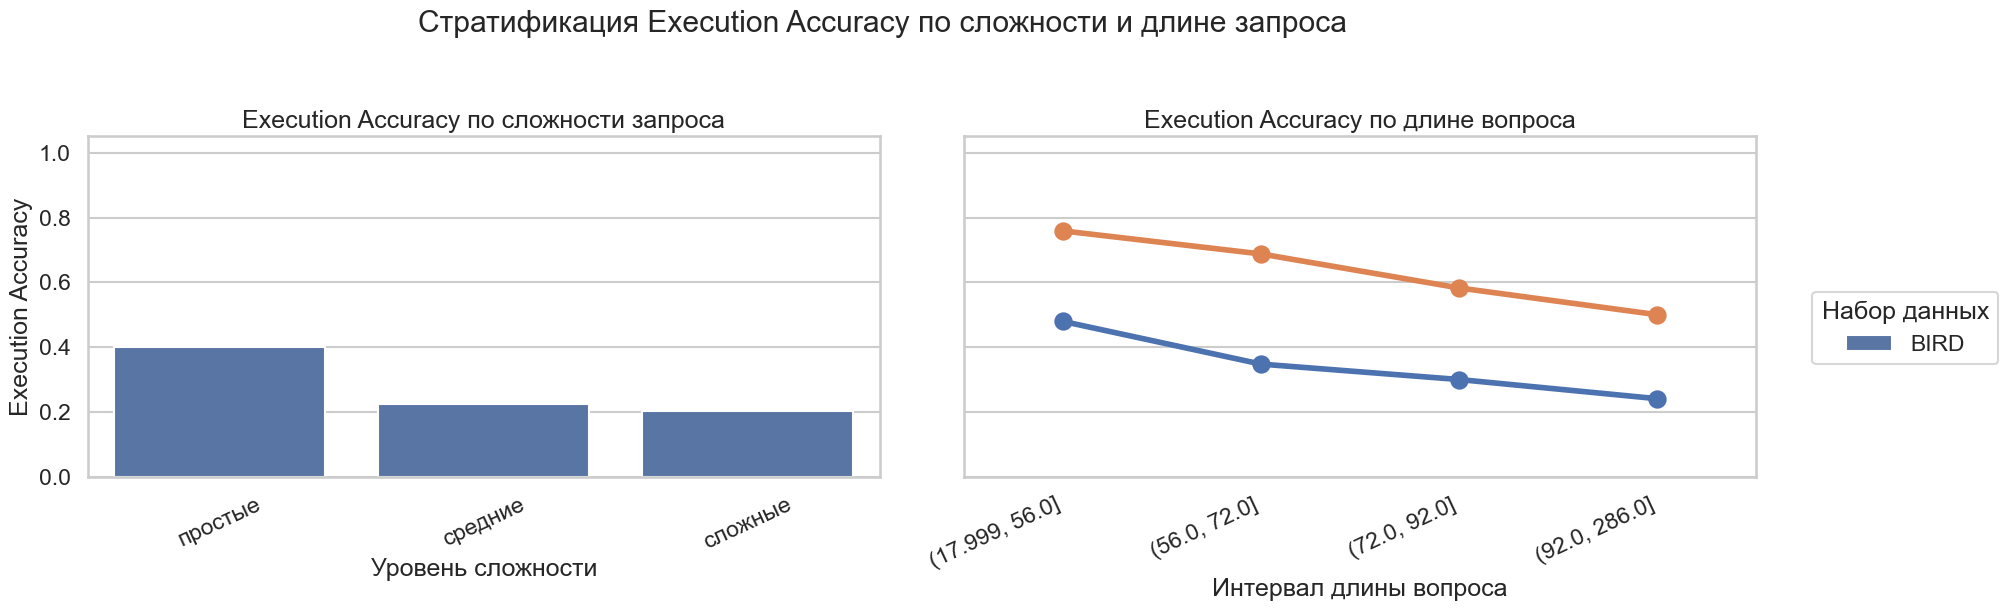

Сохранён рисунок 3.3а: /home/count/code/vkr/results/nl2sql/figures/final/figure_3_3a_ea_stratification_ru.png


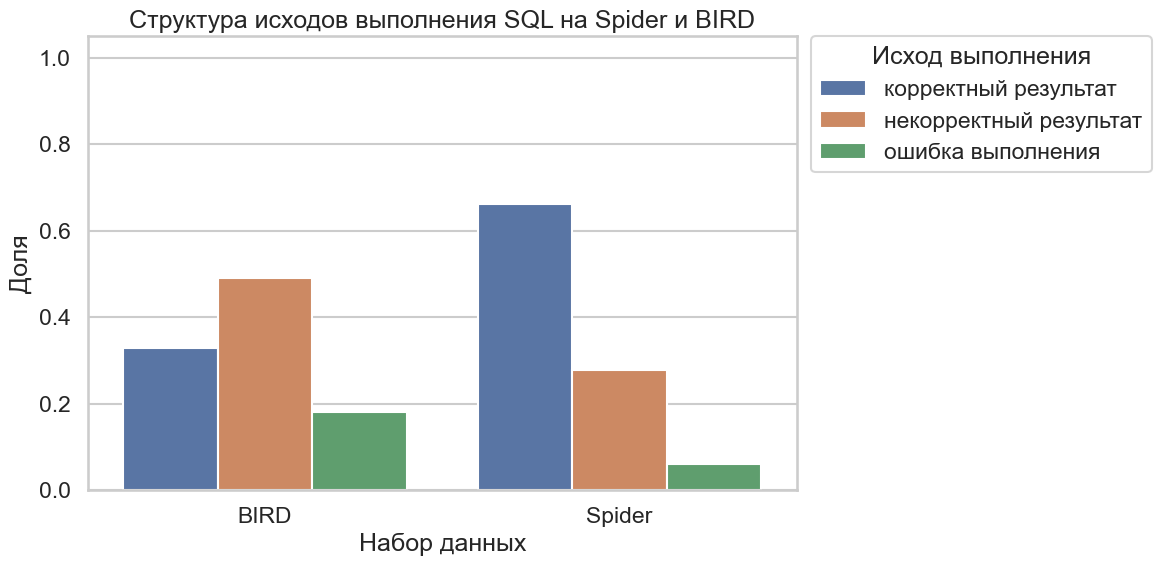

Сохранён рисунок 3.3б: /home/count/code/vkr/results/nl2sql/figures/final/figure_3_3b_sql_outcomes_ru.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

difficulty_order = [label for label in ['простые', 'средние', 'сложные'] if label in set(difficulty_df['difficulty_ru'])]
sns.barplot(
    data=difficulty_df,
    x='difficulty_ru',
    y='ea',
    hue='benchmark_ru',
    order=difficulty_order or None,
    ax=axes[0],
)
axes[0].set_title('Execution Accuracy по сложности запроса')
axes[0].set_xlabel('Уровень сложности')
axes[0].set_ylabel('Execution Accuracy')
axes[0].set_ylim(0, 1.05)
axes[0].tick_params(axis='x', rotation=25)
if axes[0].legend_ is not None:
    axes[0].legend_.remove()

sns.pointplot(
    data=question_len_df,
    x='question_len_bucket_ru',
    y='ea',
    hue='benchmark_ru',
    ax=axes[1],
)
axes[1].set_title('Execution Accuracy по длине вопроса')
axes[1].set_xlabel('Интервал длины вопроса')
axes[1].set_ylabel('Execution Accuracy')
axes[1].set_ylim(0, 1.05)
axes[1].tick_params(axis='x', rotation=25)
for label in axes[1].get_xticklabels():
    label.set_horizontalalignment('right')
if axes[1].legend_ is not None:
    axes[1].legend_.remove()

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title='Набор данных', bbox_to_anchor=(1.01, 0.5), loc='center left')
fig.suptitle('Стратификация Execution Accuracy по сложности и длине запроса', y=1.03)
fig.tight_layout()
figure_3_3a_path = FIGURES_DIR / 'figure_3_3a_ea_stratification_ru.png'
fig.savefig(figure_3_3a_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'Сохранён рисунок 3.3а: {figure_3_3a_path}')

outcome_order = [
    'корректный результат',
    'некорректный результат',
    'ошибка выполнения',
    'пустой SQL',
]
outcome_order = [label for label in outcome_order if label in set(error_mix_df['outcome_ru'])]
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(
    data=error_mix_df,
    x='benchmark_ru',
    y='share',
    hue='outcome_ru',
    hue_order=outcome_order or None,
    ax=ax,
)
ax.set_title('Структура исходов выполнения SQL на Spider и BIRD')
ax.set_xlabel('Набор данных')
ax.set_ylabel('Доля')
ax.set_ylim(0, 1.05)
ax.legend(title='Исход выполнения', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
fig.tight_layout()
figure_3_3b_path = FIGURES_DIR / 'figure_3_3b_sql_outcomes_ru.png'
fig.savefig(figure_3_3b_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'Сохранён рисунок 3.3б: {figure_3_3b_path}')


Стратифицированный анализ показывает, что снижение качества на `BIRD` связано не только с общим усложнением бенчмарка, но и с изменением структуры ошибок. По мере роста сложности и длины вопроса `EA` падает на обоих наборах, однако на `BIRD` заметно возрастает доля исходов типа `wrong_result`. Это говорит о более трудном переходе от синтаксически исполнимого запроса к семантически корректному результату.

## 8. Интегральная метрика вычислительной эффективности и ее компоненты

В этой работе вычислительная эффективность задается интегральной метрикой `Eff`, которая агрегирует ключевые характеристики вычислительного профиля модели. В текущей версии методики `Eff` рассчитывается на основе времени инференса, числа токенов и стоимости генерации.

Поэтому время инференса, число токенов и стоимость выступают не как конкурирующие метрики того же уровня, а как составляющие `Eff`. В основном тексте сначала показывается сама интегральная метрика, а затем — ее компоненты.

**Таблица 9. Интегральная метрика вычислительной эффективности**

,Модель,Бенчмарк,Интегральная метрика Eff,Нормализованная метрика Eff
2,Arctic-Text2SQL-R1-7B,bird,2212.0469,0.5689
0,ChatGPT 5.2,bird,1018.7061,0.6127
1,DeepSeek V3.2,bird,1363.8088,0.4020
3,Defog-Llama3-SQLCoder-8B q4_0,bird,512.2317,0.1753
4,Hrida-T2SQL q8_0,bird,756.4924,0.3322
7,Arctic-Text2SQL-R1-7B,spider,1676.6640,0.3271
5,ChatGPT 5.2,spider,712.3802,0.2625
6,DeepSeek V3.2,spider,1044.1776,0.1871
8,Defog-Llama3-SQLCoder-8B q4_0,spider,287.3931,0.0025
9,Hrida-T2SQL q8_0,spider,346.2196,0.0715


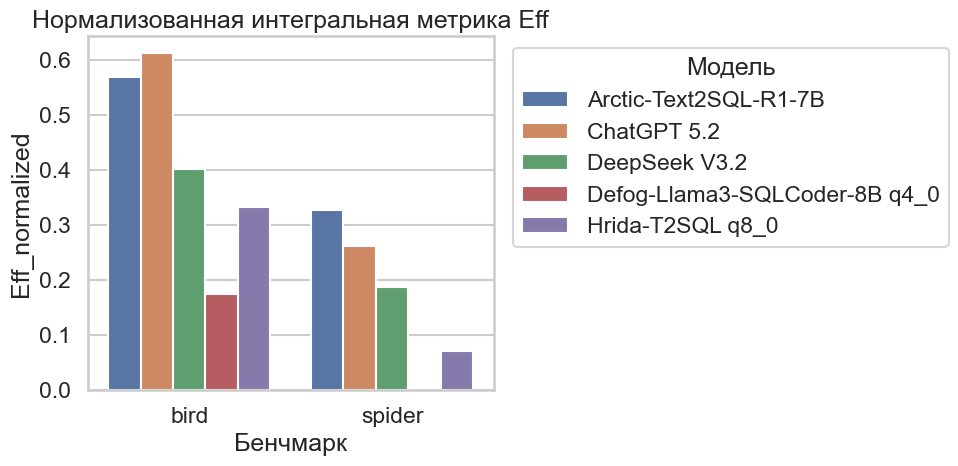

**Таблица 10. Компоненты интегральной метрики `Eff`**

,Модель,Бенчмарк,"Среднее время инференса, мс",Среднее число токенов,"Средняя стоимость, USD"
2,Arctic-Text2SQL-R1-7B,bird,6038.1180,1335.3716,0.0000
0,ChatGPT 5.2,bird,2374.4675,1021.2171,0.0019
1,DeepSeek V3.2,bird,3494.5106,1051.5183,0.0003
3,Defog-Llama3-SQLCoder-8B q4_0,bird,733.3158,974.1232,0.0000
4,Hrida-T2SQL q8_0,bird,1081.1594,1440.4817,0.0000
7,Arctic-Text2SQL-R1-7B,spider,4854.2380,734.6422,0.0000
5,ChatGPT 5.2,spider,1895.3430,479.2563,0.0009
6,DeepSeek V3.2,spider,2965.6751,514.9168,0.0002
8,Defog-Llama3-SQLCoder-8B q4_0,spider,531.0612,426.9159,0.0000
9,Hrida-T2SQL q8_0,spider,485.6148,668.4507,0.0000


**Таблица 11. Корреляция компонент интегральной метрики `Eff`**

,"Среднее время инференса, мс",Среднее число токенов,"Средняя стоимость, USD"
"Среднее время инференса, мс",1.0000,0.3020,-0.0240
Среднее число токенов,0.3020,1.0000,-0.0360
"Средняя стоимость, USD",-0.0240,-0.0360,1.0000


In [10]:
secondary_cols = ['model_display_name', 'benchmark', 'Eff', 'Eff_normalized', 'Tinf', 'Tok', 'Cost']
secondary_df = cast(Any, main_ea_df[secondary_cols].copy())
secondary_df = secondary_df.sort_values(['benchmark', 'model_display_name'])

eff_view = secondary_df[['model_display_name', 'benchmark', 'Eff', 'Eff_normalized']].copy().rename(columns={
    'model_display_name': 'Модель',
    'benchmark': 'Бенчмарк',
    'Eff': 'Интегральная метрика Eff',
    'Eff_normalized': 'Нормализованная метрика Eff',
})
display(Markdown('**Таблица 9. Интегральная метрика вычислительной эффективности**'))
display(eff_view.round(4))

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=secondary_df,
    x='benchmark',
    y='Eff_normalized',
    hue='model_display_name',
    ax=ax,
)
ax.set_title('Нормализованная интегральная метрика Eff')
ax.set_xlabel('Бенчмарк')
ax.set_ylabel('Eff_normalized')
ax.legend(title='Модель', bbox_to_anchor=(1.02, 1), loc='upper left')
fig.tight_layout()
plt.show()

component_view = secondary_df[['model_display_name', 'benchmark', 'Tinf', 'Tok', 'Cost']].copy().rename(columns={
    'model_display_name': 'Модель',
    'benchmark': 'Бенчмарк',
    'Tinf': 'Среднее время инференса, мс',
    'Tok': 'Среднее число токенов',
    'Cost': 'Средняя стоимость, USD',
})
display(Markdown('**Таблица 10. Компоненты интегральной метрики `Eff`**'))
display(component_view.round(4))

secondary_corr = secondary_df[['Tinf', 'Tok', 'Cost']].apply(pd.to_numeric, errors='coerce').corr()
secondary_corr_view = secondary_corr.rename(index={
    'Tinf': 'Среднее время инференса, мс',
    'Tok': 'Среднее число токенов',
    'Cost': 'Средняя стоимость, USD',
}, columns={
    'Tinf': 'Среднее время инференса, мс',
    'Tok': 'Среднее число токенов',
    'Cost': 'Средняя стоимость, USD',
})
display(Markdown('**Таблица 11. Корреляция компонент интегральной метрики `Eff`**'))
display(secondary_corr_view.round(3))

Раздел эффективности стоит читать как отдельное измерение сравнения: он не меняет вывода по качеству, а уточняет, каким вычислительным профилем достигается наблюдаемый `EA`. Метрика `Eff` удобна для компактного сопоставления, а таблица компонент помогает понять, за счет каких факторов складываются различия между моделями.

## 9. Ограничения исследования

Полученные результаты нужно интерпретировать с учетом нескольких ограничений. Во-первых, основной вывод относится только к сопоставимому набору моделей, включенных в сравнение, и не переносится автоматически на все большие языковые модели или все специализированные `Text2SQL`-модели. Во-вторых, `EA` остается основной метрикой качества, тогда как `Eff` задает отдельное измерение вычислительной эффективности. В-третьих, компоненты `Eff` зависят не только от свойств самих моделей, но и от среды исполнения, поэтому сравнение по эффективности описывает наблюдаемый вычислительный профиль именно в данной экспериментальной постановке.

## 10. Приложение A: Дополнительные результаты `EA`

В приложении приведены дополнительные результаты `EA`, которые расширяют контекст исследования, но не используются для основного сравнительного вывода.

In [11]:
if not appendix_ea_df.empty:
    appendix_cols = ['model_display_name', 'model_family', 'benchmark', 'n_samples', 'execution_accuracy', 'execution_accuracy_q05', 'execution_accuracy_q95', 'Tinf', 'Cost']
    appendix_view = appendix_ea_df[appendix_cols].sort_values(['benchmark', 'execution_accuracy'], ascending=[True, False]).copy()
    appendix_view = appendix_view.rename(columns={
        'model_display_name': 'Модель',
        'model_family': 'Класс модели',
        'benchmark': 'Бенчмарк',
        'n_samples': 'Число задач',
        'execution_accuracy': 'EA',
        'execution_accuracy_q05': 'EA q05',
        'execution_accuracy_q95': 'EA q95',
        'Tinf': 'Среднее время инференса, мс',
        'Cost': 'Средняя стоимость, USD',
    })
    display(Markdown('**Таблица 14. Дополнительные результаты `EA`**'))
    display(appendix_view.round(4))
else:
    display(Markdown('Дополнительные результаты `EA` отсутствуют.'))

**Таблица 14. Дополнительные результаты `EA`**

,Модель,Класс модели,Бенчмарк,Число задач,EA,EA q05,EA q95,"Среднее время инференса, мс","Средняя стоимость, USD"
0,Claude Sonnet 4.5,m1,bird,1534,0.3924,0.3735,0.4113,914.7534,0.0022
1,Claude Sonnet 4.5,m1,spider,1034,0.7640,0.7418,0.7863,1142.6548,0.0011


## 11. Приложение B: Pass@K

`Pass@K` сохраняется как дополнительная характеристика. Эта метрика полезна для обсуждения эффекта многократной генерации, однако не заменяет ни основную метрику качества `EA`, ни интегральную метрику вычислительной эффективности `Eff`.

Важно, что `pass_k` нельзя трактовать как прямое арифметическое улучшение относительно `EA` для каждой модели. Это другой режим генерации, выполняемый при иных настройках декодирования и на отдельном наборе запусков. Поэтому `pass_k` уместно использовать для сравнения моделей внутри режима многократной генерации и для оценки потенциала reranking или повторных попыток, но не как замену основным выводам по `EA` и `Eff`. Если сопоставимых результатов `pass_k` для данного среза нет, приложение не используется при формулировке итогового вывода.

In [12]:
try:
    pass_k_summary_df = cast(Any, load_summary_metrics(PASS_K_LABEL).copy())
    pass_k_audit_df = cast(Any, build_completeness_audit(PASS_K_LABEL, summary_df=pass_k_summary_df))
    pass_k_main_df = cast(Any, filter_main_report_rows(pass_k_summary_df, run_label=PASS_K_LABEL, audit_df=pass_k_audit_df))
    pass_k_appendix_df = cast(Any, filter_appendix_rows(pass_k_summary_df, run_label=PASS_K_LABEL, audit_df=pass_k_audit_df))
except FileNotFoundError:
    pass_k_audit_df = pd.DataFrame()
    pass_k_main_df = pd.DataFrame()
    pass_k_appendix_df = pd.DataFrame()

if not pass_k_main_df.empty:
    pass_cols = [col for col in ['model_display_name', 'model_family', 'benchmark', 'execution_accuracy', 'pass@1', 'pass@3', 'pass@5', 'pass@1_q05', 'pass@3_q05', 'pass@5_q05', 'pass@1_q95', 'pass@3_q95', 'pass@5_q95'] if col in pass_k_main_df.columns]
    pass_view = pass_k_main_df[pass_cols].sort_values(['benchmark', 'model_family', 'model_display_name']).copy()
    pass_view = pass_view.rename(columns={
        'model_display_name': 'Модель',
        'model_family': 'Класс модели',
        'benchmark': 'Бенчмарк',
        'execution_accuracy': 'EA в режиме pass_k',
        'pass@1': 'Pass@1',
        'pass@3': 'Pass@3',
        'pass@5': 'Pass@5',
        'pass@1_q05': 'Pass@1 q05',
        'pass@3_q05': 'Pass@3 q05',
        'pass@5_q05': 'Pass@5 q05',
        'pass@1_q95': 'Pass@1 q95',
        'pass@3_q95': 'Pass@3 q95',
        'pass@5_q95': 'Pass@5 q95',
    })
    display(Markdown('**Таблица 15. Результаты в режиме многократной генерации**'))
    display(pass_view.round(4))

    pass_k_best_overall = (
        pass_k_main_df.sort_values(['benchmark', 'pass@5'], ascending=[True, False])
        .groupby('benchmark', as_index=False)
        .first()[['benchmark', 'model_display_name', 'model_family', 'pass@1', 'pass@3', 'pass@5']]
        .rename(columns={
            'benchmark': 'Бенчмарк',
            'model_display_name': 'Лучшая модель',
            'model_family': 'Класс модели',
            'pass@1': 'Pass@1',
            'pass@3': 'Pass@3',
            'pass@5': 'Pass@5',
        })
    )
    display(Markdown('**Таблица 16. Глобально лучшие результаты в режиме многократной генерации**'))
    display(pass_k_best_overall.round(4))

    pass_k_best_by_family = (
        pass_k_main_df.sort_values(['benchmark', 'model_family', 'pass@5'], ascending=[True, True, False])
        .groupby(['benchmark', 'model_family'], as_index=False)
        .first()[['benchmark', 'model_family', 'model_display_name', 'pass@1', 'pass@3', 'pass@5']]
        .rename(columns={
            'benchmark': 'Бенчмарк',
            'model_family': 'Класс модели',
            'model_display_name': 'Лучшая модель в классе',
            'pass@1': 'Pass@1',
            'pass@3': 'Pass@3',
            'pass@5': 'Pass@5',
        })
    )
    display(Markdown('**Таблица 17. Лучшие результаты классов `M1` и `M2` в режиме многократной генерации**'))
    display(pass_k_best_by_family.round(4))
else:
    display(Markdown('Сопоставимые результаты `pass_k` отсутствуют.'))

**Таблица 15. Результаты в режиме многократной генерации**

,Модель,Класс модели,Бенчмарк,EA в режиме pass_k,Pass@1,Pass@3,Pass@5,Pass@1 q05,Pass@3 q05,Pass@5 q05,Pass@1 q95,Pass@3 q95,Pass@5 q95
0,ChatGPT 5.2,m1,bird,0.2868,0.2875,0.3524,0.3735,0.2690,0.3339,0.3533,0.3044,0.3724,0.3937
1,DeepSeek V3.2,m1,bird,0.3175,0.3201,0.3482,0.3611,0.3009,0.3288,0.3422,0.3407,0.3675,0.3807
2,Arctic-Text2SQL-R1-7B,m2,bird,0.2132,0.2116,0.2253,0.2347,0.1949,0.2070,0.2158,0.2288,0.2425,0.2529
3,Defog-Llama3-SQLCoder-8B q4_0,m2,bird,0.1258,0.1279,0.1456,0.1571,0.1147,0.1317,0.1427,0.1403,0.1596,0.1721
4,Hrida-T2SQL q8_0,m2,bird,0.0378,0.0342,0.0375,0.0404,0.0274,0.0297,0.0326,0.0421,0.0455,0.0489
5,ChatGPT 5.2,m1,spider,0.7418,0.7424,0.7637,0.7718,0.7211,0.7423,0.7505,0.7640,0.7856,0.7921
6,DeepSeek V3.2,m1,spider,0.7379,0.7395,0.7619,0.7698,0.7170,0.7396,0.7476,0.7603,0.7841,0.7892
7,Arctic-Text2SQL-R1-7B,m2,spider,0.5522,0.5538,0.5750,0.5890,0.5308,0.5511,0.5638,0.5793,0.6012,0.6132
8,Defog-Llama3-SQLCoder-8B q4_0,m2,spider,0.4323,0.4300,0.4683,0.4942,0.4068,0.4435,0.4681,0.4549,0.4932,0.5184
9,Hrida-T2SQL q8_0,m2,spider,0.3414,0.3468,0.3656,0.3772,0.3236,0.3406,0.3530,0.3724,0.3894,0.3994


**Таблица 16. Глобально лучшие результаты в режиме многократной генерации**

,Бенчмарк,Лучшая модель,Класс модели,Pass@1,Pass@3,Pass@5
0,bird,ChatGPT 5.2,m1,0.2875,0.3524,0.3735
1,spider,ChatGPT 5.2,m1,0.7424,0.7637,0.7718


**Таблица 17. Лучшие результаты классов `M1` и `M2` в режиме многократной генерации**

,Бенчмарк,Класс модели,Лучшая модель в классе,Pass@1,Pass@3,Pass@5
0,bird,m1,ChatGPT 5.2,0.2875,0.3524,0.3735
1,bird,m2,Arctic-Text2SQL-R1-7B,0.2116,0.2253,0.2347
2,spider,m1,ChatGPT 5.2,0.7424,0.7637,0.7718
3,spider,m2,Arctic-Text2SQL-R1-7B,0.5538,0.5750,0.5890


## 12. Приложение C: Результаты локального синтетического бенчмарка

В данном приложении приведены результаты дополнительного локального сценария `synthetic_ecommerce`, подготовленного как авторский локальный датасет для ограниченного e-commerce-домена. Этот сценарий не используется для основного сравнительного вывода по `Spider` и `BIRD`, однако позволяет дополнительно рассмотреть поведение моделей в контролируемом `SQLite`-окружении с фиксированной схемой, детерминированным заполнением базы и execution-based процедурой оценки.

Принципиально важно, что локальный синтетический бенчмарк не предназначен для прямого сравнения абсолютных значений `EA` с `Spider` и `BIRD`. Его назначение состоит в проверке поведения моделей на фиксированной схеме, воспроизводимых данных и управляемых уровнях сложности. Поэтому результаты данного приложения следует интерпретировать как дополнительный аналитический срез, а не как альтернативу основным внешним benchmark-корпусам.


In [13]:
import json

SYNTH_RESULTS_ROOT = Path('results') / 'nl2sql' / 'synthetic_benchmark'
SYNTH_PASSK_ROOT = SYNTH_RESULTS_ROOT / 'pass_k'
SYNTH_FIGURES_DIR = FIGURES_DIR / 'synthetic_appendix'
SYNTH_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

SYNTH_MODEL_META = {
    'm1_deepseek': {'display_name': 'DeepSeek', 'model_family': 'm1'},
    'm1_chatgpt': {'display_name': 'ChatGPT', 'model_family': 'm1'},
    'm2_defog': {'display_name': 'Defog-Llama3-SQLCoder-8B', 'model_family': 'm2'},
    'm2_hrida': {'display_name': 'Hrida-T2SQL', 'model_family': 'm2'},
    'm2_arctic': {'display_name': 'Arctic-Text2SQL-R1-7B', 'model_family': 'm2'},
}


def _load_json(path: Path):
    with path.open('r', encoding='utf-8') as fh:
        return json.load(fh)


def _iter_model_dirs(root: Path, mode: str):
    if not root.exists():
        return []
    if mode == 'ea':
        return sorted([p for p in root.iterdir() if p.is_dir() and p.name not in {'pass_k', 'smoke', 'figures'}])
    return sorted([p for p in root.iterdir() if p.is_dir()])


def _load_synthetic_summary(root: Path, mode: str):
    rows = []
    difficulty_rows = []
    for result_dir in _iter_model_dirs(root, mode):
        results_path = result_dir / 'results.json'
        if not results_path.exists():
            continue
        payload = _load_json(results_path)
        meta = SYNTH_MODEL_META.get(result_dir.name, {'display_name': result_dir.name, 'model_family': 'other'})
        row = {
            'model_key': result_dir.name,
            'model_display_name': meta['display_name'],
            'model_family': meta['model_family'],
            'mode': mode,
            **payload['overall'],
        }
        rows.append(row)
        for difficulty, metrics in payload.get('by_difficulty', {}).items():
            difficulty_rows.append({
                'model_key': result_dir.name,
                'model_display_name': meta['display_name'],
                'model_family': meta['model_family'],
                'mode': mode,
                'difficulty': difficulty,
                **metrics,
            })
    return pd.DataFrame(rows), pd.DataFrame(difficulty_rows)


synthetic_ea_df, synthetic_ea_difficulty_df = _load_synthetic_summary(SYNTH_RESULTS_ROOT, mode='ea')
synthetic_passk_df, synthetic_passk_difficulty_df = _load_synthetic_summary(SYNTH_PASSK_ROOT, mode='pass_k')
synthetic_pass_cols = sorted(
    [col for col in synthetic_passk_df.columns if col.startswith('pass@') and '_ci_' not in col and '_q' not in col],
    key=lambda col: int(col.split('@', 1)[1]),
) if not synthetic_passk_df.empty else []

synthetic_spec_df = pd.DataFrame([
    {'Характеристика': 'Предметная область', 'Значение': 'e-commerce analytics'},
    {'Характеристика': 'Схема базы данных', 'Значение': '6 таблиц'},
    {'Характеристика': 'Основное ядро SQL', 'Значение': '30 запросов'},
    {'Характеристика': 'Распределение по сложности', 'Значение': '10 easy / 10 medium / 10 hard'},
    {'Характеристика': 'Дополнительные edge-case сценарии', 'Значение': '8 запросов'},
    {'Характеристика': 'Исполняемая база данных', 'Значение': 'фиксированный snapshot SQLite'},
    {'Характеристика': 'Основные метрики', 'Значение': 'EA, Valid SQL Rate, Pass@K'},
])

display(Markdown('**Таблица 18. Краткая спецификация локального синтетического бенчмарка**'))
display(synthetic_spec_df)
display(Markdown(f'**Источник результатов локального синтетического бенчмарка:** `{SYNTH_RESULTS_ROOT}`'))
display(Markdown(f'Доступно моделей в режиме `EA`: {len(synthetic_ea_df)}; в режиме `pass_k`: {len(synthetic_passk_df)}.'))


**Таблица 18. Краткая спецификация локального синтетического бенчмарка**

,Характеристика,Значение
0,Предметная область,e-commerce analytics
1,Схема базы данных,6 таблиц
2,Основное ядро SQL,30 запросов
3,Распределение по сложности,10 easy / 10 medium / 10 hard
4,Дополнительные edge-case сценарии,8 запросов
5,Исполняемая база данных,фиксированный snapshot SQLite
6,Основные метрики,"EA, Valid SQL Rate, Pass@K"


**Источник результатов локального синтетического бенчмарка:** `results/nl2sql/synthetic_benchmark`

Доступно моделей в режиме `EA`: 5; в режиме `pass_k`: 5.

Сначала рассматриваются результаты single-shot режима `EA`, поскольку именно этот режим соответствует основной логике сравнения качества первого выбранного SQL-запроса. Затем отдельно приводятся результаты режима `pass_k`, позволяющие оценить, в какой степени многократная генерация увеличивает вероятность получения корректного SQL-запроса.

`Pass@K` не является прямым аналогом `EA`. Метрика `EA` характеризует качество одного выбранного ответа, тогда как `Pass@K` оценивает вероятность того, что среди нескольких кандидатов присутствует корректный SQL-запрос. Следовательно, значения `Pass@K` следует трактовать как оценку достижимого качества при многократной генерации и наличии механизма отбора кандидатов, а не как прямую замену `EA`.


**Таблица 19. Результаты локального синтетического бенчмарка в режиме `EA`**

,Модель,Класс модели,EA,Доля исполнимых SQL,EA (easy),EA (medium),EA (hard)
1,DeepSeek,m1,0.8333,1.0000,1.0000,0.8000,0.7000
0,ChatGPT,m1,0.7000,0.8333,0.8000,0.7000,0.6000
2,Arctic-Text2SQL-R1-7B,m2,0.7333,1.0000,1.0000,0.7000,0.5000
4,Hrida-T2SQL,m2,0.7333,1.0000,1.0000,0.8000,0.4000
3,Defog-Llama3-SQLCoder-8B,m2,0.6333,0.9000,1.0000,0.7000,0.2000


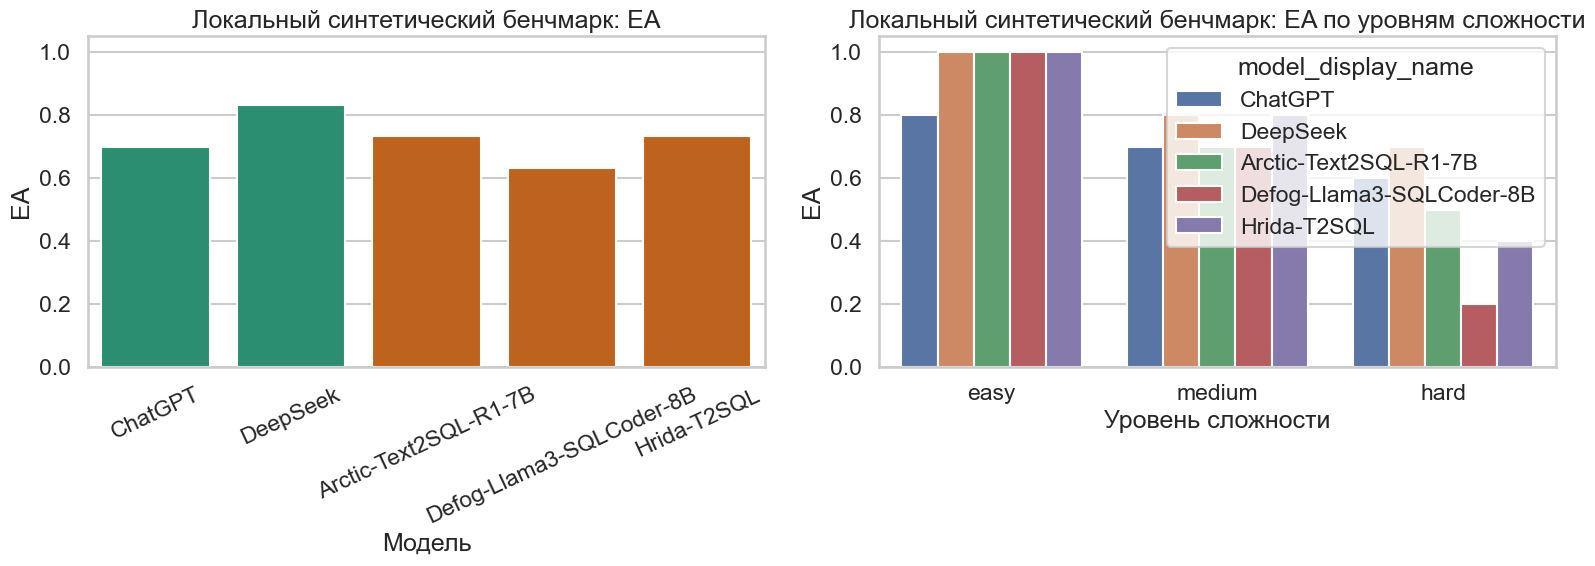

**Таблица 20. Результаты локального синтетического бенчмарка в режиме `pass_k`**

,Модель,Класс модели,EA в режиме pass_k,Доля исполнимых SQL,pass@1,pass@3,pass@5
1,DeepSeek,m1,0.8333,1.0000,0.8133,0.8333,0.8333
0,ChatGPT,m1,0.7000,0.8333,0.7133,0.7333,0.7333
2,Arctic-Text2SQL-R1-7B,m2,0.7667,0.9667,0.7733,0.8200,0.8333
4,Hrida-T2SQL,m2,0.6333,0.8333,0.6133,0.7367,0.7667
3,Defog-Llama3-SQLCoder-8B,m2,0.5333,0.7667,0.5267,0.6600,0.7000


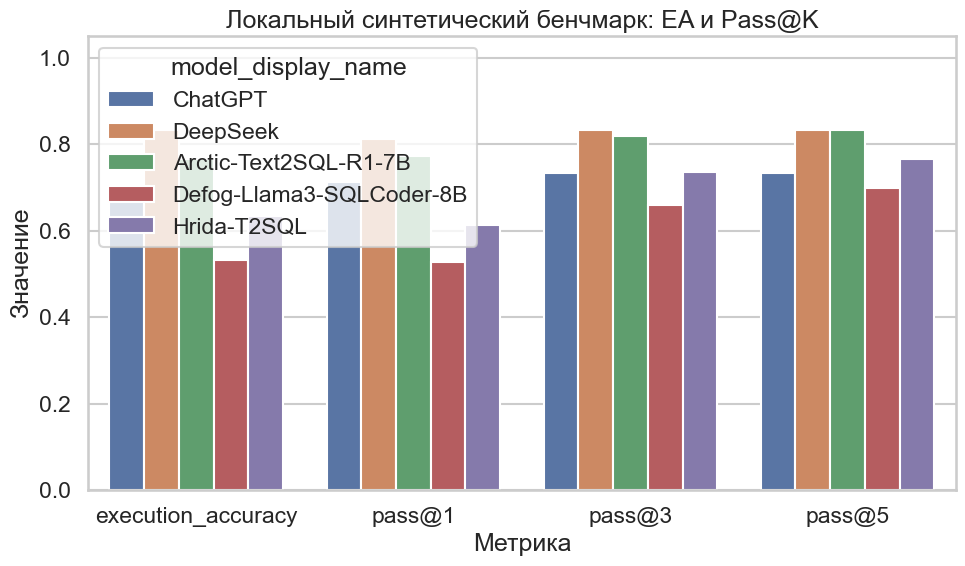

In [14]:
if not synthetic_ea_df.empty:
    synthetic_ea_view = synthetic_ea_df[['model_display_name', 'model_family', 'execution_accuracy', 'valid_sql_rate']].copy()
    ea_difficulty_pivot = (
        synthetic_ea_difficulty_df
        .pivot(index='model_display_name', columns='difficulty', values='execution_accuracy')
        .reindex(columns=['easy', 'medium', 'hard'])
        .reset_index()
    )
    synthetic_ea_view = synthetic_ea_view.merge(ea_difficulty_pivot, on='model_display_name', how='left')
    synthetic_ea_view = synthetic_ea_view.rename(columns={
        'model_display_name': 'Модель',
        'model_family': 'Класс модели',
        'execution_accuracy': 'EA',
        'valid_sql_rate': 'Доля исполнимых SQL',
        'easy': 'EA (easy)',
        'medium': 'EA (medium)',
        'hard': 'EA (hard)',
    })
    display(Markdown('**Таблица 19. Результаты локального синтетического бенчмарка в режиме `EA`**'))
    display(synthetic_ea_view.sort_values(['Класс модели', 'EA'], ascending=[True, False]).round(4))

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    sns.barplot(data=synthetic_ea_df, x='model_display_name', y='execution_accuracy', hue='model_family', dodge=False, ax=axes[0], palette=palette)
    axes[0].set_title('Локальный синтетический бенчмарк: EA')
    axes[0].set_xlabel('Модель')
    axes[0].set_ylabel('EA')
    axes[0].set_ylim(0, 1.05)
    axes[0].tick_params(axis='x', rotation=25)

    sns.barplot(data=synthetic_ea_difficulty_df, x='difficulty', y='execution_accuracy', hue='model_display_name', order=['easy', 'medium', 'hard'], ax=axes[1])
    axes[1].set_title('Локальный синтетический бенчмарк: EA по уровням сложности')
    axes[1].set_xlabel('Уровень сложности')
    axes[1].set_ylabel('EA')
    axes[1].set_ylim(0, 1.05)

    if axes[0].legend_ is not None:
        axes[0].legend_.remove()
    plt.tight_layout()
    plt.savefig(SYNTH_FIGURES_DIR / 'synthetic_appendix_ea.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    display(Markdown('Результаты локального синтетического бенчмарка в режиме `EA` отсутствуют.'))

if not synthetic_passk_df.empty:
    passk_cols = ['model_display_name', 'model_family', 'execution_accuracy', 'valid_sql_rate', *synthetic_pass_cols]
    synthetic_passk_view = synthetic_passk_df[passk_cols].copy().rename(columns={
        'model_display_name': 'Модель',
        'model_family': 'Класс модели',
        'execution_accuracy': 'EA в режиме pass_k',
        'valid_sql_rate': 'Доля исполнимых SQL',
    })
    display(Markdown('**Таблица 20. Результаты локального синтетического бенчмарка в режиме `pass_k`**'))
    display(synthetic_passk_view.sort_values(['Класс модели', synthetic_pass_cols[-1] if synthetic_pass_cols else 'EA в режиме pass_k'], ascending=[True, False]).round(4))

    passk_plot_df = synthetic_passk_df.melt(
        id_vars=['model_display_name'],
        value_vars=['execution_accuracy', *synthetic_pass_cols],
        var_name='metric',
        value_name='score',
    )
    plt.figure(figsize=(10, 6))
    sns.barplot(data=passk_plot_df, x='metric', y='score', hue='model_display_name')
    plt.title('Локальный синтетический бенчмарк: EA и Pass@K')
    plt.xlabel('Метрика')
    plt.ylabel('Значение')
    plt.ylim(0, 1.05)
    plt.tight_layout()
    plt.savefig(SYNTH_FIGURES_DIR / 'synthetic_appendix_passk.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    display(Markdown('Результаты локального синтетического бенчмарка в режиме `pass_k` отсутствуют.'))


Результаты локального синтетического бенчмарка показывают, что все модели демонстрируют высокое качество на `easy`-запросах, тогда как основные различия между ними проявляются на уровнях `medium` и `hard`. Именно в этой части набора становится заметна деградация качества, и именно здесь различия между моделями оказываются наиболее информативными.

В режиме single-shot на данном локальном наборе наилучшее значение `EA` показала модель DeepSeek. Среди специализированных моделей класса `M2` наилучший результат показала Arctic-Text2SQL-R1-7B. В режиме `pass_k` модель Arctic также сохраняет лучший результат внутри класса `M2`, причём основной прирост достигается уже при переходе от одного кандидата к нескольким первым попыткам генерации.

Дополнительно следует учитывать, что первичные эксперименты с недоопределёнными NL-запросами приводили к резкому снижению `EA` даже при относительно высоком уровне `Valid SQL Rate`. После добавления явного grounding по таблицам, колонкам, `JOIN`, `GROUP BY` и агрегатным операциям значения `EA` существенно выросли. Это подтверждает, что качество формулировки NL-запроса является самостоятельным фактором качества `NL2SQL`-систем.

Снижение `Valid SQL Rate` у ChatGPT в данном сценарии частично связано не с логической ошибкой SQL, а с несовпадением SQL-диалекта и формата ответа: модель возвращала PostgreSQL-style литералы дат и JSON-объекты, требующие дополнительного post-processing перед выполнением в `SQLite`. Поэтому интерпретация результатов ChatGPT в приложении C должна учитывать не только собственно качество генерации SQL, но и форматно-диалектные расхождения между ответом модели и исполняющей средой.

Таким образом, локальный синтетический бенчмарк расширяет аналитический контекст исследования, однако не заменяет внешний benchmark-корпус `Spider` и `BIRD`, на котором формулируется основной сравнительный вывод работы.


## 13. Итоговые выводы

В заключительном разделе формулируется итоговая интерпретация результатов исследования применительно к проверяемой гипотезе, различиям между классами моделей и границам применимости полученного вывода.


In [15]:
best_by_family = cast(Any, best_by_family_df.set_index(['benchmark', 'model_family']))
spider_m1 = best_by_family.loc[('spider', 'm1')]
spider_m2 = best_by_family.loc[('spider', 'm2')]
bird_m1 = best_by_family.loc[('bird', 'm1')]
bird_m2 = best_by_family.loc[('bird', 'm2')]

main_pivot = main_ea_df.pivot(index='model_name', columns='benchmark', values='execution_accuracy')
avg_gap = float((main_pivot['spider'] - main_pivot['bird']).mean())
spider_wrong = float(error_mix_df[(error_mix_df['benchmark'] == 'spider') & (error_mix_df['error_type'] == 'wrong_result')]['share'].iloc[0])
bird_wrong = float(error_mix_df[(error_mix_df['benchmark'] == 'bird') & (error_mix_df['error_type'] == 'wrong_result')]['share'].iloc[0])

conclusion_text = f"""
Основной вывод работы строится по сопоставимым результатам `EA` для моделей, включенных в основное сравнение. На бенчмарке `Spider` лучший представитель класса `M2` ({spider_m2['model_display_name']}, {spider_m2['execution_accuracy']:.1%}) показывает качество, близкое к лучшему представителю класса `M1` ({spider_m1['model_display_name']}, {spider_m1['execution_accuracy']:.1%}). На `BIRD` лучший представитель класса `M2` ({bird_m2['model_display_name']}, {bird_m2['execution_accuracy']:.1%}) заметно превосходит лучший результат класса `M1` ({bird_m1['model_display_name']}, {bird_m1['execution_accuracy']:.1%}).

Экспериментальные данные показывают, что специализированная компактная модель может обеспечивать качество генерации SQL, сопоставимое с качеством большой универсальной модели. При этом такой вывод не следует автоматически переносить на весь класс `M2`: внутри класса наблюдается существенный разброс качества. Кроме того, абсолютный уровень качества остается ограниченным: ни одна из моделей основного сравнения на `BIRD` не достигает диапазона `EA = 0.8-0.9`, поэтому говорить о практической решенности задачи NL2SQL на сложном реалистичном бенчмарке пока нельзя.

Отдельно важен разрыв между самими бенчмарками. В среднем результаты на `Spider` выше результатов на `BIRD` на {avg_gap:.1%}, а доля исходов типа `wrong_result` возрастает с {spider_wrong:.1%} на `Spider` до {bird_wrong:.1%} на `BIRD`. Это показывает, что более реалистичный бенчмарк существенно меняет картину сравнения моделей.

Часть гипотезы, связанная с вычислительной эффективностью, интерпретируется через интегральную метрику `Eff` и ее компоненты. Метрика `Pass@K` рассматривается как дополнительная характеристика поведения моделей в режиме многократной генерации и не заменяет основной вывод по `EA`.

Дополнительный вывод состоит в том, что практическая применимость NL2SQL существенно зависит от масштаба и структурной сложности системы. На подготовленном авторском локальном датасете `synthetic_ecommerce` для ограниченного e-commerce-домена качество генерации оказалось высоким: `DeepSeek V3.2` получил `EA = 83.3%` на core-наборе из 30 запросов по схеме из 6 таблиц. Это показывает, что NL2SQL может быть практически применим в ограниченных предметных областях с фиксированной схемой и контролируемым набором типовых запросов. При этом такой результат нельзя переносить на крупные и неоднородные системы: основные бенчмарки подтверждают это ограничение, поскольку при переходе от `Spider` к более сложному `BIRD` качество заметно снижается, а доля `wrong_result` растет. Следовательно, даже большие general-purpose LLM не гарантируют высокую эффективность при усложнении схемы, предметной области и пользовательских запросов.
"""
display(Markdown(conclusion_text))


Основной вывод работы строится по сопоставимым результатам `EA` для моделей, включенных в основное сравнение. На бенчмарке `Spider` лучший представитель класса `M2` (Arctic-Text2SQL-R1-7B, 77.2%) показывает качество, близкое к лучшему представителю класса `M1` (ChatGPT 5.2, 74.3%). На `BIRD` лучший представитель класса `M2` (Arctic-Text2SQL-R1-7B, 53.8%) заметно превосходит лучший результат класса `M1` (ChatGPT 5.2, 36.6%).

Экспериментальные данные показывают, что специализированная компактная модель может обеспечивать качество генерации SQL, сопоставимое с качеством большой универсальной модели. При этом такой вывод не следует автоматически переносить на весь класс `M2`: внутри класса наблюдается существенный разброс качества. Кроме того, абсолютный уровень качества остается ограниченным: ни одна из моделей основного сравнения на `BIRD` не достигает диапазона `EA = 0.8-0.9`, поэтому говорить о практической решенности задачи NL2SQL на сложном реалистичном бенчмарке пока нельзя.

Отдельно важен разрыв между самими бенчмарками. В среднем результаты на `Spider` выше результатов на `BIRD` на 33.2%, а доля исходов типа `wrong_result` возрастает с 27.9% на `Spider` до 49.0% на `BIRD`. Это показывает, что более реалистичный бенчмарк существенно меняет картину сравнения моделей.

Часть гипотезы, связанная с вычислительной эффективностью, интерпретируется через интегральную метрику `Eff` и ее компоненты. Метрика `Pass@K` рассматривается как дополнительная характеристика поведения моделей в режиме многократной генерации и не заменяет основной вывод по `EA`.

Дополнительный вывод состоит в том, что практическая применимость NL2SQL существенно зависит от масштаба и структурной сложности системы. На подготовленном авторском локальном датасете `synthetic_ecommerce` для ограниченного e-commerce-домена качество генерации оказалось высоким: `DeepSeek V3.2` получил `EA = 83.3%` на core-наборе из 30 запросов по схеме из 6 таблиц. Это показывает, что NL2SQL может быть практически применим в ограниченных предметных областях с фиксированной схемой и контролируемым набором типовых запросов. При этом такой результат нельзя переносить на крупные и неоднородные системы: основные бенчмарки подтверждают это ограничение, поскольку при переходе от `Spider` к более сложному `BIRD` качество заметно снижается, а доля `wrong_result` растет. Следовательно, даже большие general-purpose LLM не гарантируют высокую эффективность при усложнении схемы, предметной области и пользовательских запросов.
